# Supermarket Sales Analysis

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

In [42]:
df = pd.read_csv('Supermarket_Sales.csv')
df.head()

,Invoice ID,Branch,City,Customer Type,Gender,Product Line,Unit Price,Quantity,Tax 5%,Total,Date,Time,Payment,COGS,Gross Margin Percentage,Gross Income,Rating
0,INV-100000,A,Yangon,Member,Female,Sports and travel,286.76,2,28.68,602.20,2023-05-11,16:41,Credit card,573.52,4.76,28.68,8.7
1,INV-100001,A,Yangon,Member,Female,Home and lifestyle,246.49,7,86.27,1811.70,2023-08-10,20:51,Cash,1725.43,4.76,86.27,7.5
2,INV-100002,A,Yangon,Member,Male,Sports and travel,451.21,1,22.56,473.77,2023-01-12,19:13,Credit card,451.21,4.76,22.56,8.4
3,INV-100003,C,Naypyitaw,Member,Female,Electronic accessories,114.74,8,45.90,963.82,2023-09-11,19:14,Credit card,917.92,4.76,45.90,9.7
4,INV-100004,A,Yangon,Member,Male,Fashion accessories,211.01,9,94.95,1994.04,2023-11-25,20:55,Credit card,1899.09,4.76,94.95,4.7


In [43]:
df.shape

(1000, 17)

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer Type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product Line             1000 non-null   str    
 6   Unit Price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  COGS                     1000 non-null   float64
 14  Gross Margin Percentage  1000 non-nu

In [45]:
df.describe()

,Unit Price,Quantity,Tax 5%,Total,COGS,Gross Margin Percentage,Gross Income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00,1000.000000,1000.000000
mean,255.600040,5.397000,68.248450,1433.209330,1364.960880,4.76,68.248450,6.973300
std,145.843603,2.877442,57.281401,1202.906759,1145.625358,0.00,57.281401,1.751526
min,6.420000,1.000000,0.360000,7.570000,7.210000,4.76,0.360000,4.000000
25%,126.675000,3.000000,22.237500,467.040000,444.802500,4.76,22.237500,5.400000
50%,257.430000,5.000000,53.585000,1125.260000,1071.675000,4.76,53.585000,7.000000
75%,384.912500,8.000000,96.820000,2033.280000,1936.460000,4.76,96.820000,8.500000
max,499.970000,10.000000,249.710000,5243.910000,4994.200000,4.76,249.710000,10.000000


In [46]:
df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer Type              0
Gender                     0
Product Line               0
Unit Price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
COGS                       0
Gross Margin Percentage    0
Gross Income               0
Rating                     0
dtype: int64

In [47]:
df.duplicated().sum()

np.int64(0)

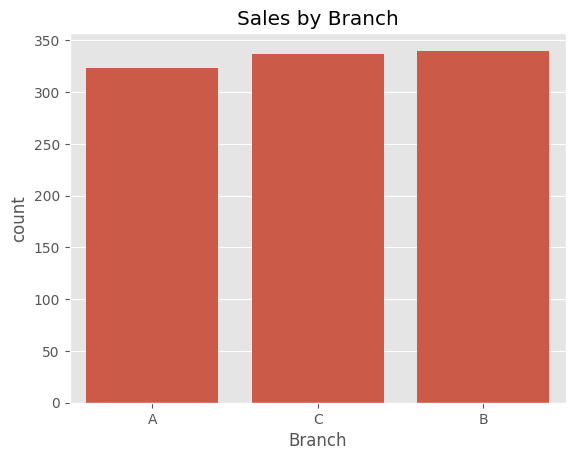

In [48]:
sns.countplot(x='Branch',data=df)
plt.title('Sales by Branch')
plt.show()

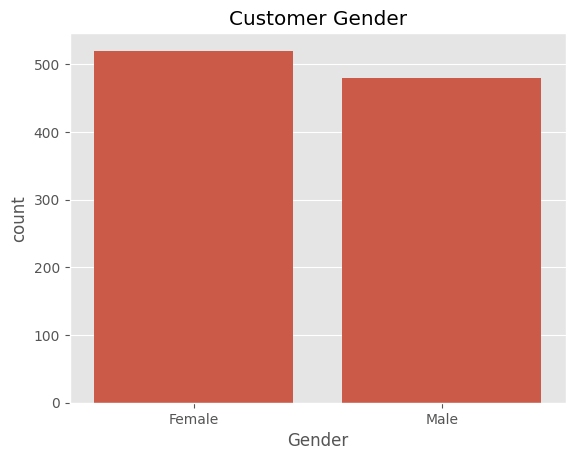

In [49]:
sns.countplot(x='Gender',data=df)
plt.title('Customer Gender')
plt.show()

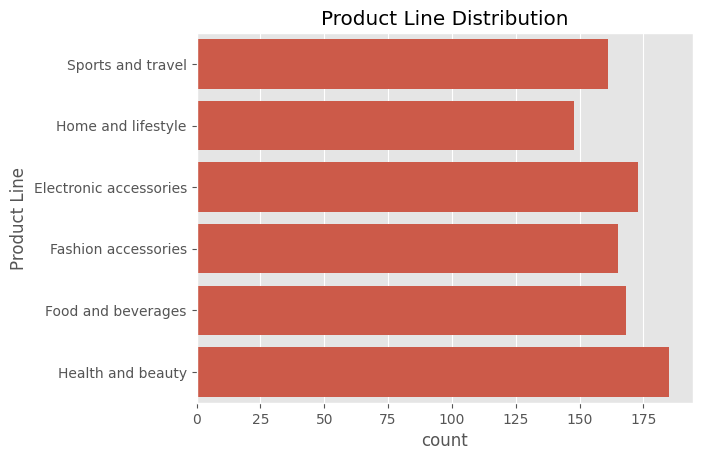

In [50]:
sns.countplot(y='Product Line',data=df)
plt.title('Product Line Distribution')
plt.show()

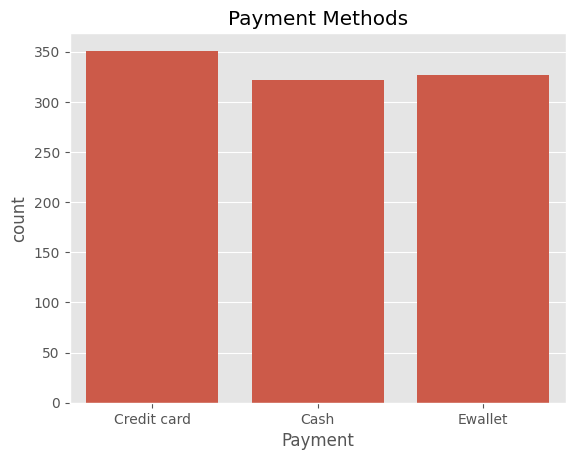

In [51]:
sns.countplot(x='Payment',data=df)
plt.title('Payment Methods')
plt.show()

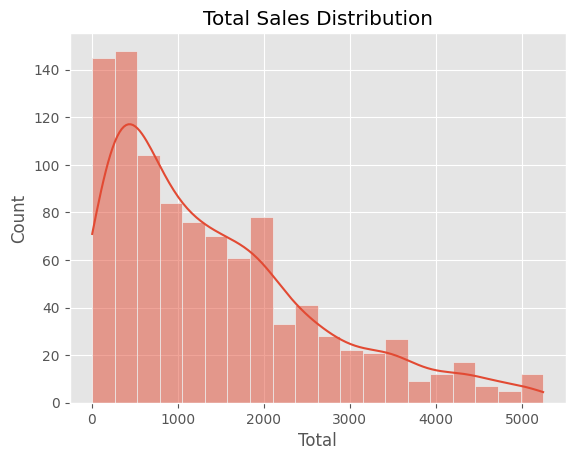

In [52]:
sns.histplot(df['Total'],bins=20,kde=True)
plt.title('Total Sales Distribution')
plt.show()

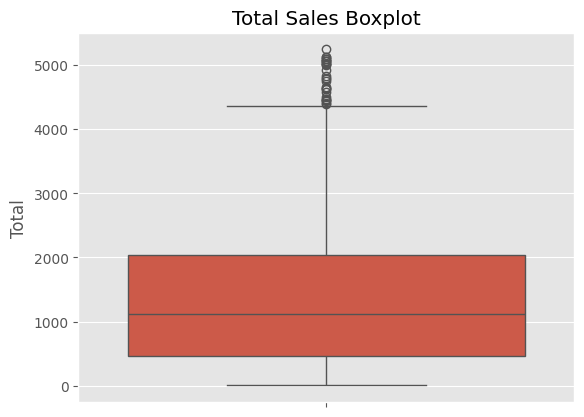

In [53]:
sns.boxplot(y=df['Total'])
plt.title('Total Sales Boxplot')
plt.show()

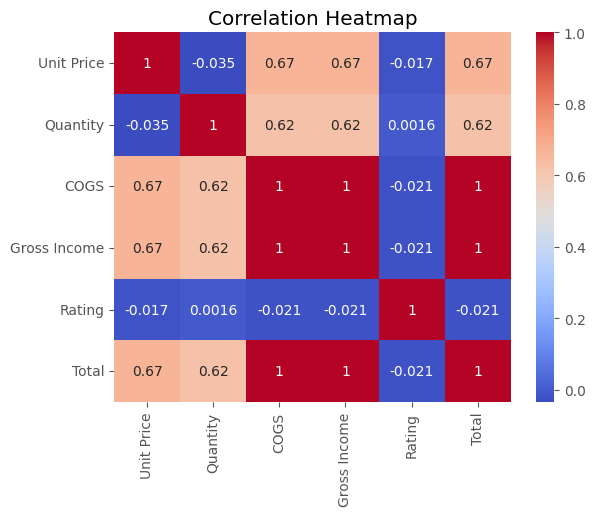

In [54]:
corr=df[['Unit Price','Quantity','COGS','Gross Income','Rating','Total']].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

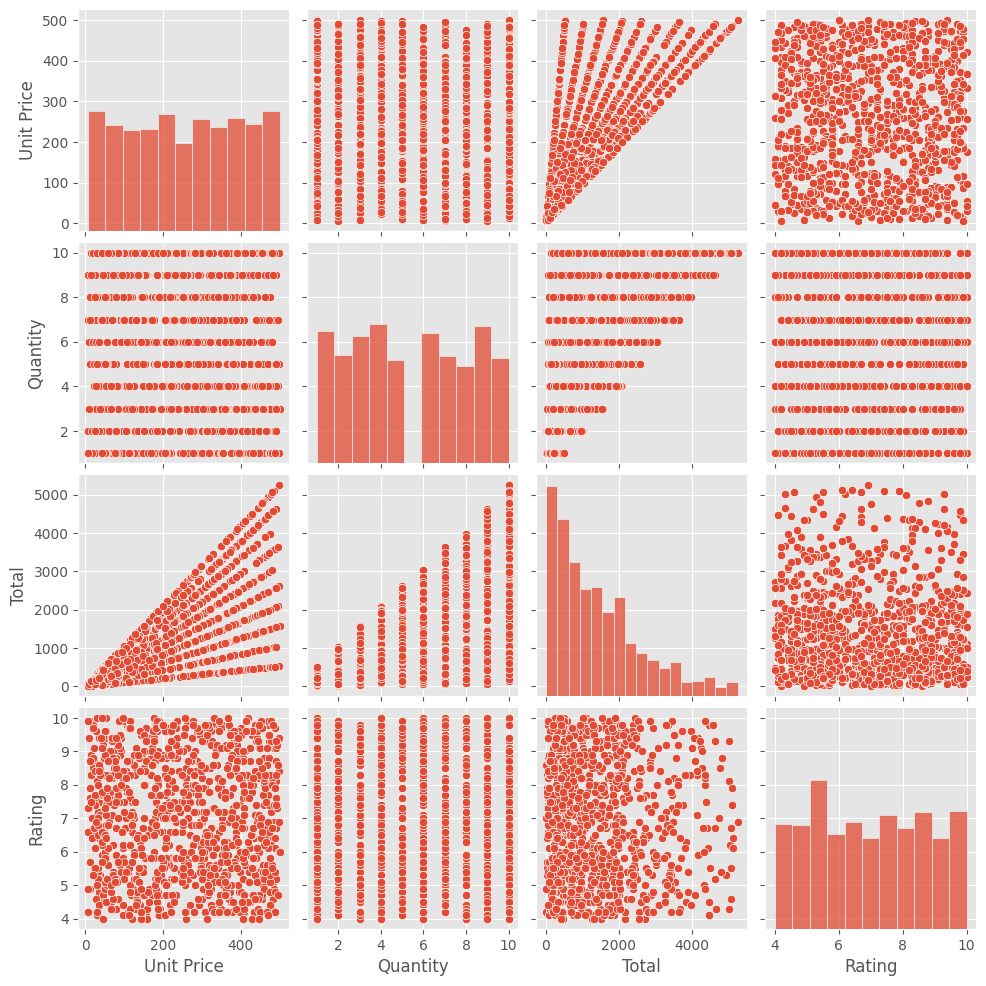

In [55]:
sns.pairplot(df[['Unit Price','Quantity','Total','Rating']])
plt.show()

In [56]:
branch_sales=df.groupby('Branch')['Total'].sum()
print(branch_sales)

Branch
A    463599.22
B    473726.76
C    495883.35
Name: Total, dtype: float64


In [57]:
city_sales=df.groupby('City')['Total'].sum()
print(city_sales)

City
Mandalay     473726.76
Naypyitaw    495883.35
Yangon       463599.22
Name: Total, dtype: float64


In [58]:
product_sales=df.groupby('Product Line')['Total'].sum().sort_values(ascending=False)
print(product_sales)

Product Line
Health and beauty         265023.89
Food and beverages        260243.90
Fashion accessories       246331.53
Sports and travel         226544.16
Electronic accessories    221323.29
Home and lifestyle        213742.56
Name: Total, dtype: float64


In [59]:
df.to_csv('Cleaned_Supermarket_Sales.csv',index=False)
print('Supermarket_Sales_Analysis Completed Successfully!')

Supermarket_Sales_Analysis Completed Successfully!
